# 4.6 - Replay + LwF

Stored exemplars and a frozen self-teacher together. This is iCaRL.

Same memory as 4.5, since the LwF half is free.

## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "embeddings"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [ ]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "xx"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /kaggle/input/ucf101-action-recognition/
ULAL_OUTPUT_ROOT  = /kaggle/working/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
GPU       : Tesla T4 (15.6 GB)
Classes   : base=10 t1=10 t2=10 t3=10 t4=10


42

## **Preprocess data**

In [ ]:
# rebuild clip roots clean (a prior run may have written the leaky split here)
for _root in [cfg.BASE_ROOT, cfg.TASK1_ROOT, cfg.TASK2_ROOT]:
    if os.path.isdir(_root):
        shutil.rmtree(_root)

# BASE
base_split = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT)

# TASK 1
task1_split = build_group_split(cfg.TASK_1, train_groups=18, val_groups=3)
preprocess_group_split(task1_split, cfg.TASK_1, output_root=cfg.TASK1_ROOT)

# TASK 2
task2_split = build_group_split(cfg.TASK_2, train_groups=18, val_groups=3)
preprocess_group_split(task2_split, cfg.TASK_2, output_root=cfg.TASK2_ROOT)

In [ ]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [7]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats', 'Bowling']


In [ ]:
# The cache fixes the label space, so it is built once here for all tasks.
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2

class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(f"\nclass_to_idx:\n{class_to_idx}")


class_to_idx:
{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BandMarching': 15, 'BlowDryHair': 16, 'BlowingCandles': 17, 'BodyWeightSquats': 18, 'Bowling': 19, 'BoxingPunchingBag': 20, 'BoxingSpeedBag': 21, 'BrushingTeeth': 22, 'CliffDiving': 23, 'CricketBowling': 24, 'CricketShot': 25, 'CuttingInKitchen': 26, 'FieldHockeyPenalty': 27, 'Haircut': 28, 'SoccerPenalty': 29}


## **Create Loaders**

In [9]:
CACHE, LSTM_STATE, META = load_feature_cache(cfg.FEAT_CACHE)
check_cache_labels(META, ALL_CLASSES_LIST)

TASK_CLASSES = [cfg.SELECTED_CLASSES, cfg.TASK_1, cfg.TASK_2]
TASK_ROOTS   = [cfg.BASE_ROOT, cfg.TASK1_ROOT, cfg.TASK2_ROOT]
TASK_NAMES   = ["Base", "Task1", "Task2"]

base_test_loader  = emb_loaders(CACHE, [0], "test")[1]
task1_test_loader = emb_loaders(CACHE, [1], "test")[1]
task2_test_loader = emb_loaders(CACHE, [2], "test")[1]

combined_test_loader  = emb_loaders(CACHE, [0, 1], "test")[1]
combined_test_loader2 = emb_loaders(CACHE, [0, 1, 2], "test")[1]

base_train,  base_y   = task_split(CACHE, 0, "train")
base_val,    base_vy  = task_split(CACHE, 0, "val")
task1_train, task1_y  = task_split(CACHE, 1, "train")
task1_val,   task1_vy = task_split(CACHE, 1, "val")
task2_train, task2_y  = task_split(CACHE, 2, "train")
task2_val,   task2_vy = task_split(CACHE, 2, "val")

print(f"base  test {len(base_test_loader.dataset)}")
print(f"task1 test {len(task1_test_loader.dataset)}")
print(f"task2 test {len(task2_test_loader.dataset)}")

Loaded 9 tensors, 526 MB in RAM
  per clip: (16, 2048)
base  test 212
task1 test 217
task2 test 226


## **Upload Model**

In [10]:
ARM_KEY  = "replay_lwf"
ARM_NAME = "Replay+LwF"
KD_LAMBDA, KD_T = cfg.LAMBDA_DISTILL, 5.0
ARM_CONFIG = {"mechanism": "replay+lwf", "per_class": 15, "kd_lambda": KD_LAMBDA, "kd_T": KD_T}

CL_EPOCHS, CL_LR, CL_WD, CL_BATCH, CL_LS = 15, 5e-4, 0.03, 32, 0.10

head_base = load_or_train_base_head(
    f"{cfg.CKPT_DIR}/head_base.pt", CACHE, LSTM_STATE, len(cfg.SELECTED_CLASSES), device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
)

Loaded base head <- /content/drive/MyDrive/apai/checkpoints/head_base.pt


In [11]:
buffer = SmartReplayBuffer(max_per_class=15)
fill_buffer(buffer, base_train, base_y, cfg.SELECTED_CLASSES, class_to_idx, "hard")

teacher1 = snapshot_teacher(head_base)

head_task1 = expand_head(copy.deepcopy(head_base), len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1))
model_task1 = ModelWrapper(head_task1).to(device)

In [12]:
results_baseline = evaluate_all_tasks(
    model            = model_task1,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.9009  Loss=0.9683
  task1_only       -> Acc=0.0184  Loss=3.1715
  combined_t1      -> Acc=0.4545  Loss=2.0827


In [13]:
print(f"head_task1 classifier: in={head_task1.classifier.in_features}  out={head_task1.classifier.out_features}")

head_task1 classifier: in=256  out=20


## **Task One**

In [14]:
set_seed(cfg.SEED)

head_task1, train_task1 = train_task(
    head_task1, task1_train, task1_y, task1_val, task1_vy, device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
    buffer=buffer, teacher=teacher1, kd_lambda=KD_LAMBDA, kd_T=KD_T,
    num_old_classes=len(cfg.SELECTED_CLASSES),
    tag=ARM_KEY,
)
model_task1 = ModelWrapper(head_task1).to(device)

Epoch [1/15] | Train Acc: 0.6584 Loss: 1.6030 | Val Acc: 0.7974 Loss: 0.8505
  [replay_lwf] ep 01/15 | CE 1.6030 | KD 0.2224
Epoch [2/15] | Train Acc: 0.9273 Loss: 0.8746 | Val Acc: 0.8301 Loss: 0.7188
Epoch [3/15] | Train Acc: 0.9779 Loss: 0.7537 | Val Acc: 0.8170 Loss: 0.7574
Epoch [4/15] | Train Acc: 0.9954 Loss: 0.7084 | Val Acc: 0.8431 Loss: 0.6924
Epoch [5/15] | Train Acc: 0.9991 Loss: 0.6833 | Val Acc: 0.8235 Loss: 0.7159
Epoch [6/15] | Train Acc: 1.0000 Loss: 0.6727 | Val Acc: 0.8497 Loss: 0.6335
Epoch [7/15] | Train Acc: 0.9982 Loss: 0.6672 | Val Acc: 0.8235 Loss: 0.7605
Epoch [8/15] | Train Acc: 0.9991 Loss: 0.6615 | Val Acc: 0.8301 Loss: 0.7036
Epoch [9/15] | Train Acc: 0.9982 Loss: 0.6566 | Val Acc: 0.8170 Loss: 0.7069
Epoch [10/15] | Train Acc: 0.9991 Loss: 0.6546 | Val Acc: 0.8170 Loss: 0.7325
Epoch [11/15] | Train Acc: 0.9991 Loss: 0.6539 | Val Acc: 0.8170 Loss: 0.7261
Epoch [12/15] | Train Acc: 0.9991 Loss: 0.6542 | Val Acc: 0.8170 Loss: 0.7249
Epoch [13/15] | Train Acc

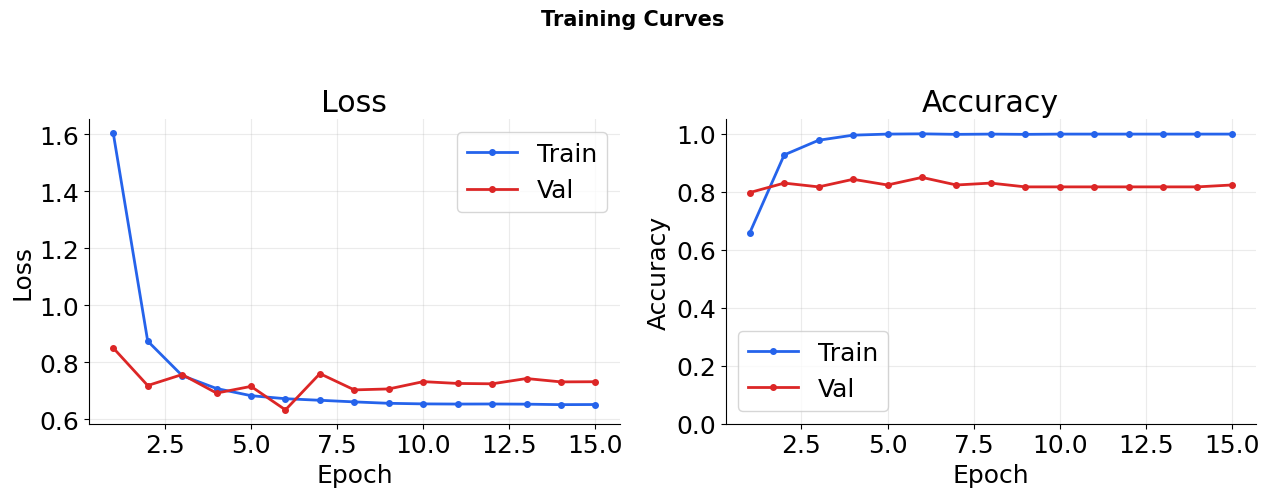

In [15]:
plot_training_results(train_task1)

In [16]:
results_after_t1 = evaluate_all_tasks(
    model            = model_task1,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.8113  Loss=0.8410
  task1_only       -> Acc=0.8848  Loss=0.4808
  combined_t1      -> Acc=0.8485  Loss=0.6588


Running Inference on Test Set...


Test Accuracy: 0.8485


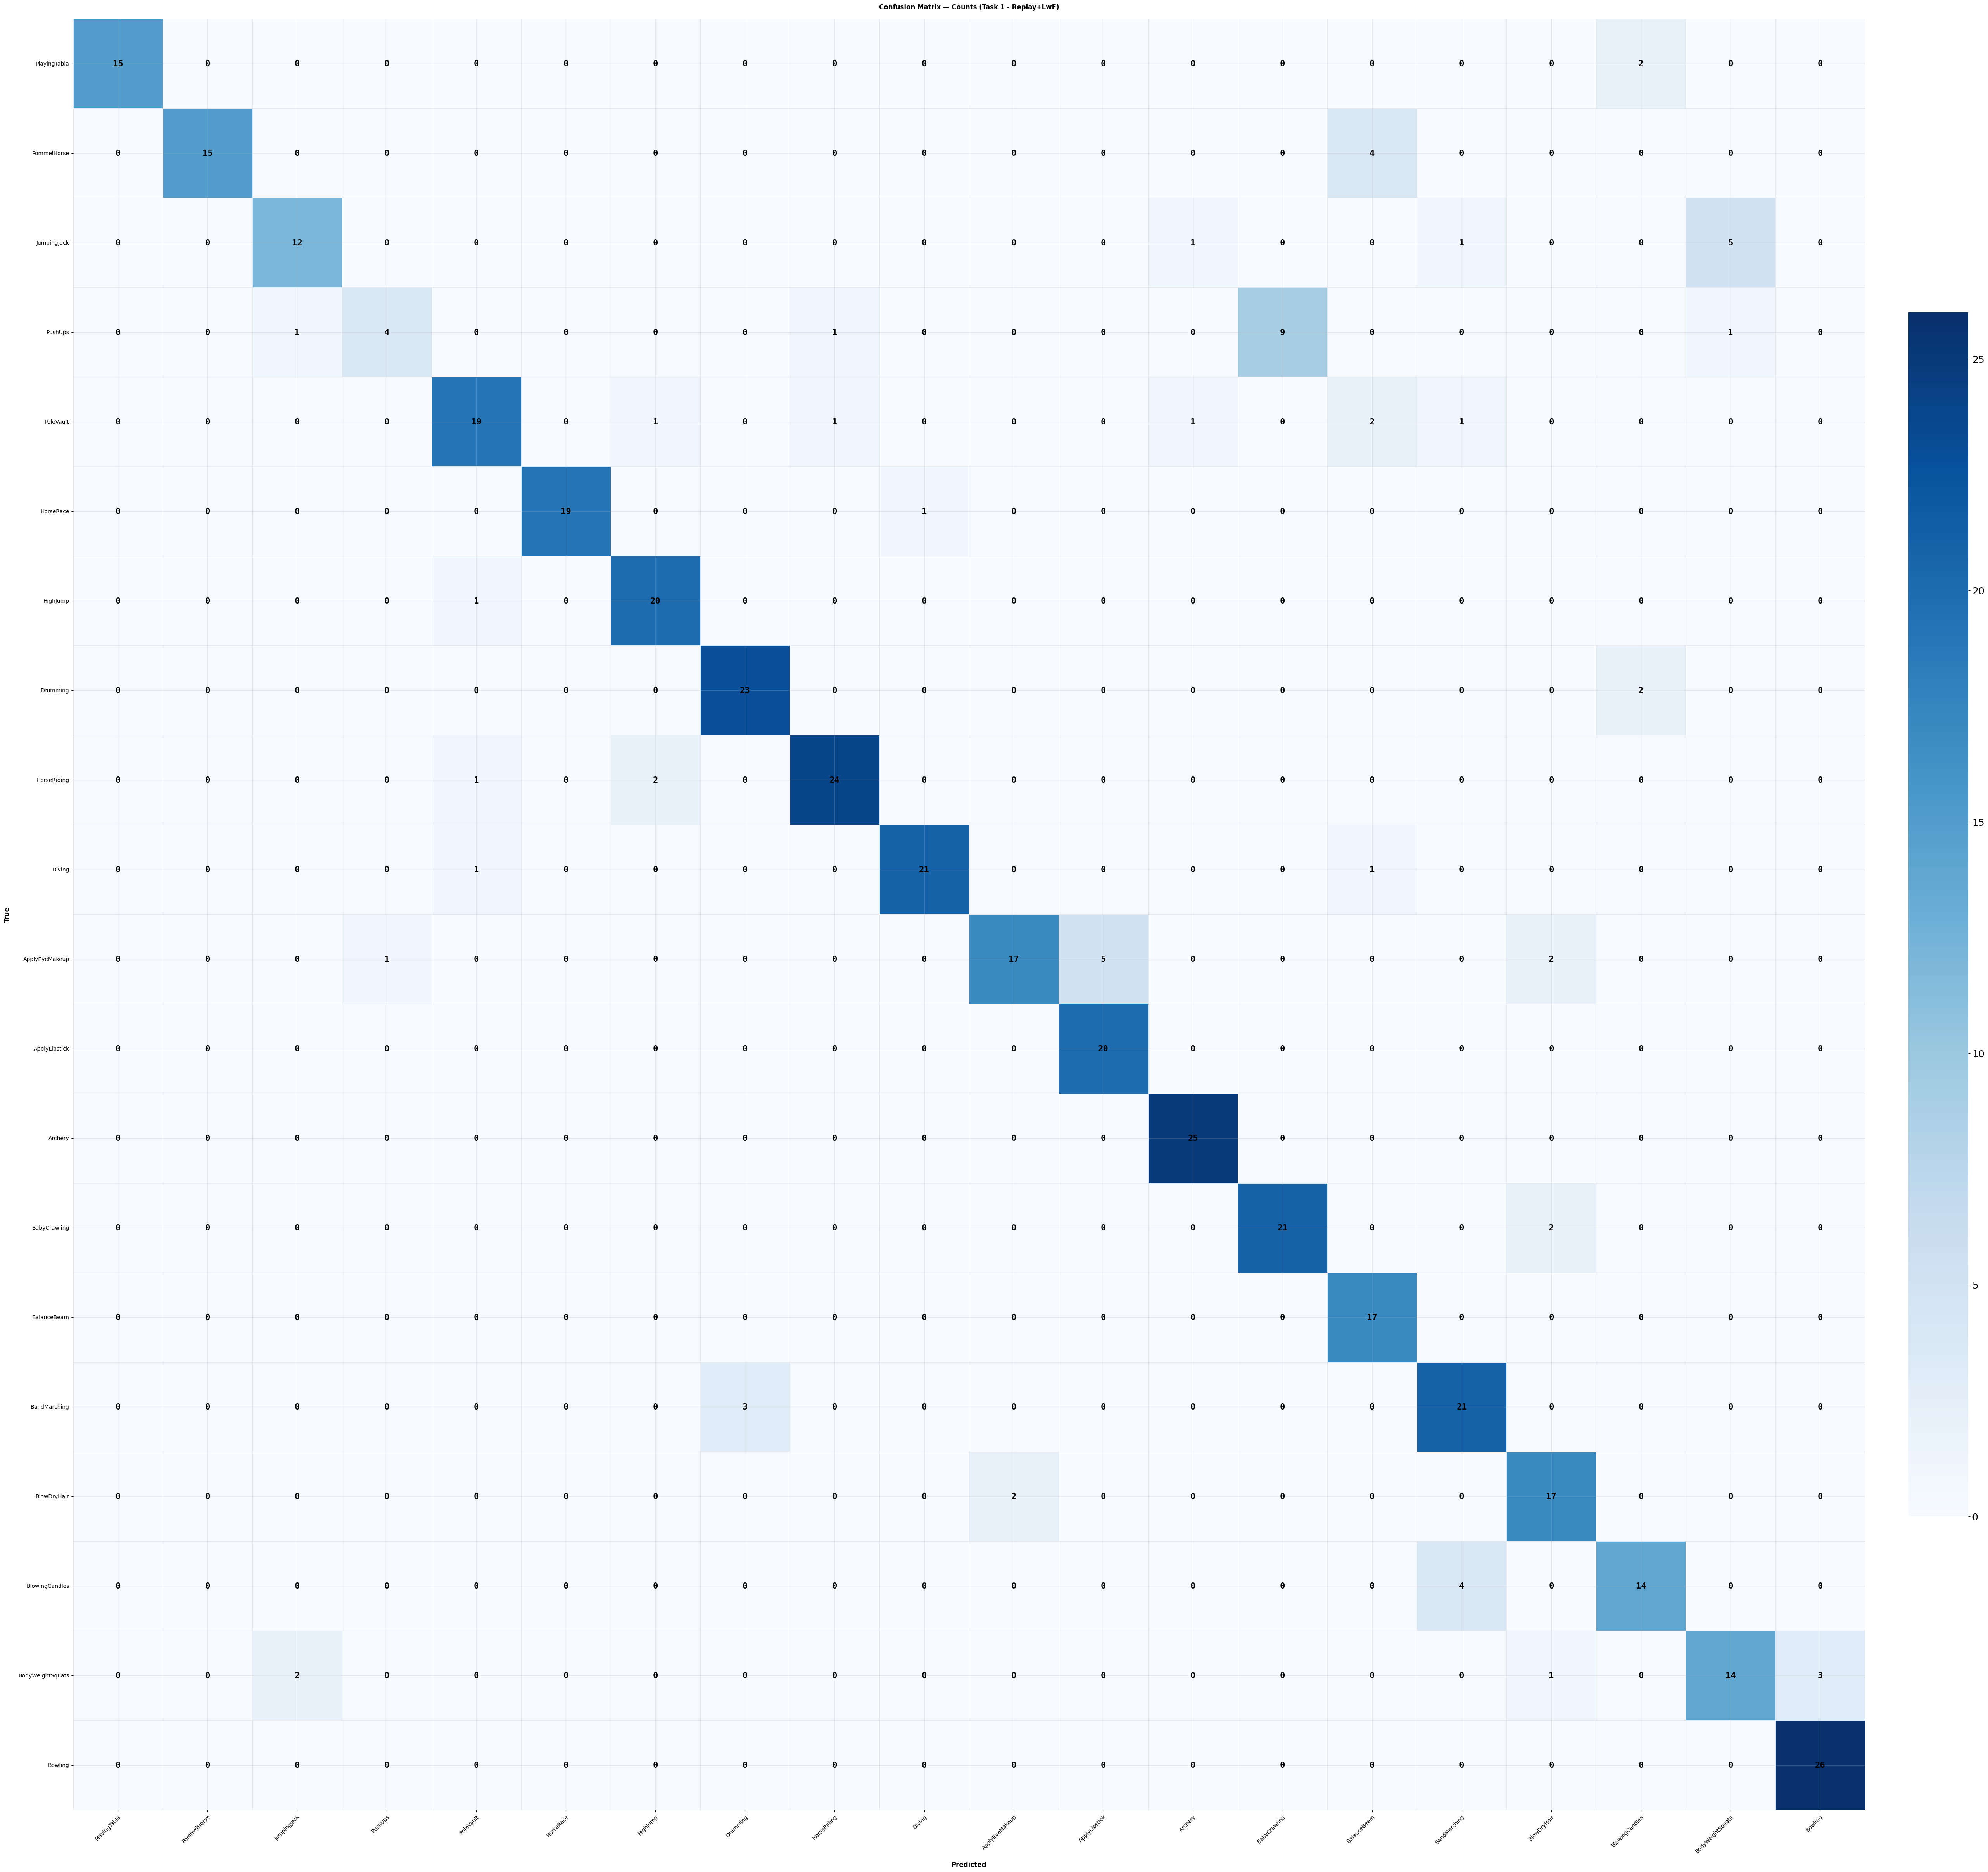

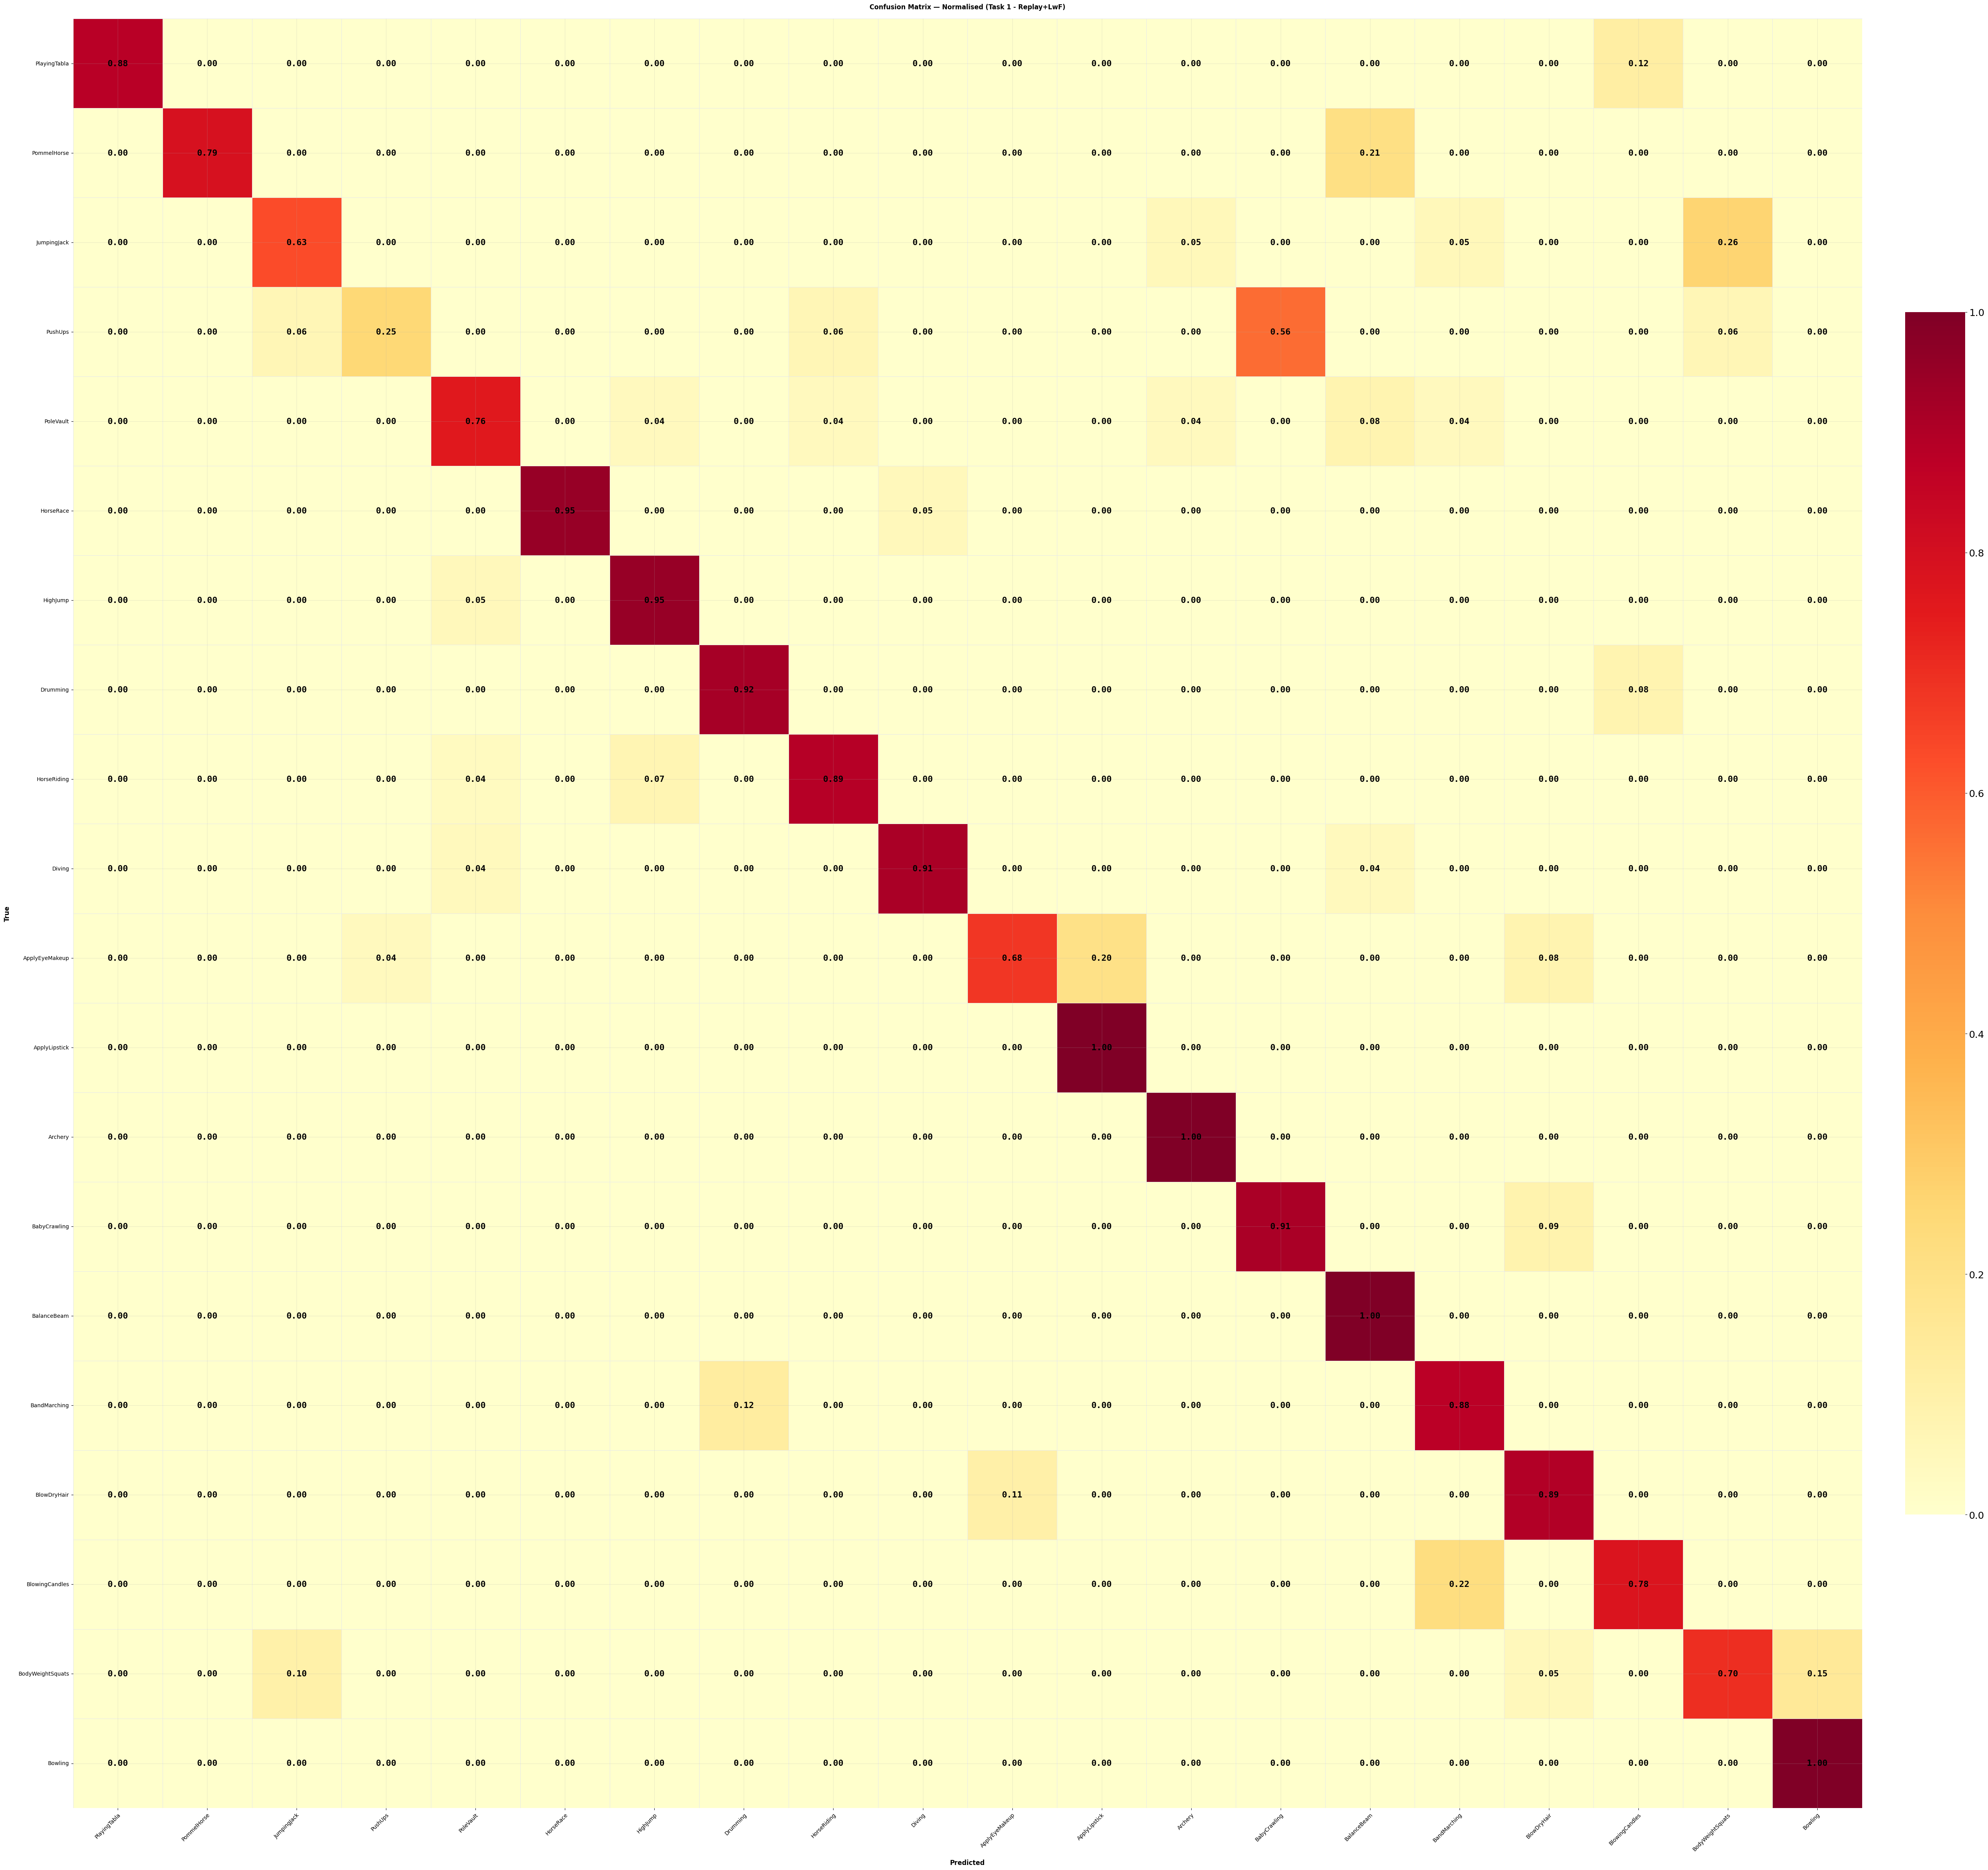

In [17]:
_, all_preds, all_labels = test_model(model_task1, combined_test_loader, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
    classes_list = ALL_CLASSES_LIST,
    name         = f"Task 1 - {ARM_NAME}",
)

In [18]:
print_detailed_metrics(
    all_labels   = all_labels,
    all_preds    = all_preds,
    num_classes  = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
    classes_list = ALL_CLASSES_LIST,
    split_old    = (0, len(cfg.SELECTED_CLASSES)),
    split_new    = (len(cfg.SELECTED_CLASSES), len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1)),
)


METRICS FOR 20 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.8485
  Precision : 0.8559
  Recall    : 0.8485
  F1-Score  : 0.8416

PER-CLASS REPORT 
                  precision    recall  f1-score   support

    PlayingTabla       1.00      0.88      0.94        17
     PommelHorse       1.00      0.79      0.88        19
     JumpingJack       0.80      0.63      0.71        19
         PushUps       0.80      0.25      0.38        16
       PoleVault       0.86      0.76      0.81        25
       HorseRace       1.00      0.95      0.97        20
        HighJump       0.87      0.95      0.91        21
        Drumming       0.88      0.92      0.90        25
     HorseRiding       0.92      0.89      0.91        27
          Diving       0.95      0.91      0.93        23
  ApplyEyeMakeup       0.89      0.68      0.77        25
   ApplyLipstick       0.80      1.00      0.89        20
         Archery       0.93      1.00      0.96        25
    BabyCrawling       0.70      

## **Task 2**

In [19]:
fill_buffer(buffer, task1_train, task1_y, cfg.TASK_1, class_to_idx, "hard")

teacher2 = snapshot_teacher(head_task1)


head_task2 = expand_head(head_task1, len(ALL_CLASSES_LIST))
model_task2 = ModelWrapper(head_task2).to(device)

In [20]:
results_baseline = evaluate_all_tasks(
    model            = model_task2,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader, task2_test_loader],
    combined_loaders = [combined_test_loader, combined_test_loader2],
)

  base             -> Acc=0.8113  Loss=1.0223
  task1_only       -> Acc=0.8848  Loss=0.5927
  task2_only       -> Acc=0.0000  Loss=4.1524
  combined_t1      -> Acc=0.8485  Loss=0.8050
  combined_t2      -> Acc=0.5557  Loss=1.9600


In [21]:
set_seed(cfg.SEED)

head_task2, train_task2 = train_task(
    head_task2, task2_train, task2_y, task2_val, task2_vy, device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
    buffer=buffer, teacher=teacher2, kd_lambda=KD_LAMBDA, kd_T=KD_T,
    num_old_classes=len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
    tag=ARM_KEY,
)
model_task2 = ModelWrapper(head_task2).to(device)

Epoch [1/15] | Train Acc: 0.6871 Loss: 1.5989 | Val Acc: 0.8038 Loss: 0.7214
  [replay_lwf] ep 01/15 | CE 1.5989 | KD 0.2583
Epoch [2/15] | Train Acc: 0.9551 Loss: 0.9171 | Val Acc: 0.8228 Loss: 0.7089
Epoch [3/15] | Train Acc: 0.9837 Loss: 0.8104 | Val Acc: 0.7911 Loss: 0.6701
Epoch [4/15] | Train Acc: 0.9985 Loss: 0.7622 | Val Acc: 0.8481 Loss: 0.6752
Epoch [5/15] | Train Acc: 0.9992 Loss: 0.7405 | Val Acc: 0.8101 Loss: 0.7774
Epoch [6/15] | Train Acc: 0.9992 Loss: 0.7340 | Val Acc: 0.8418 Loss: 0.7019
Epoch [7/15] | Train Acc: 1.0000 Loss: 0.7257 | Val Acc: 0.8101 Loss: 0.7595
Epoch [8/15] | Train Acc: 1.0000 Loss: 0.7225 | Val Acc: 0.8165 Loss: 0.7787
Epoch [9/15] | Train Acc: 1.0000 Loss: 0.7212 | Val Acc: 0.8228 Loss: 0.7817
Epoch [10/15] | Train Acc: 1.0000 Loss: 0.7169 | Val Acc: 0.7911 Loss: 0.8332
Epoch [11/15] | Train Acc: 1.0000 Loss: 0.7156 | Val Acc: 0.7975 Loss: 0.8395
Epoch [12/15] | Train Acc: 1.0000 Loss: 0.7150 | Val Acc: 0.8038 Loss: 0.8534
Epoch [13/15] | Train Acc

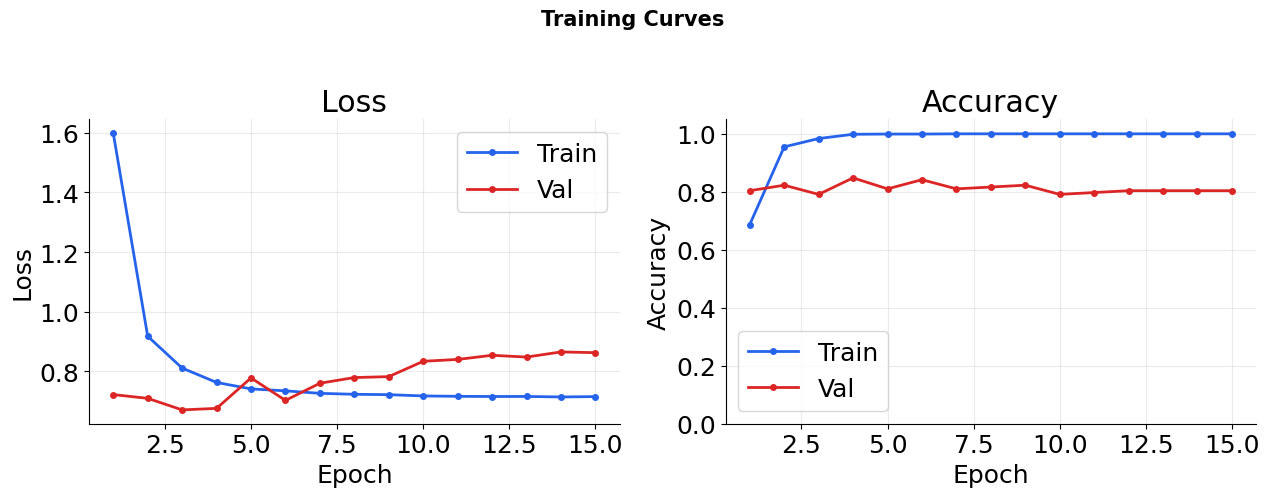

In [22]:
plot_training_results(train_task2)

In [23]:
results_after_t2 = evaluate_all_tasks(
    model            = model_task2,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader, task2_test_loader],
    combined_loaders = [combined_test_loader, combined_test_loader2],
)

  base             -> Acc=0.7689  Loss=0.9364
  task1_only       -> Acc=0.7742  Loss=0.8881
  task2_only       -> Acc=0.7788  Loss=0.8462
  combined_t1      -> Acc=0.7716  Loss=0.9120
  combined_t2      -> Acc=0.7740  Loss=0.8893


Running Inference on Test Set...


Test Accuracy: 0.7740


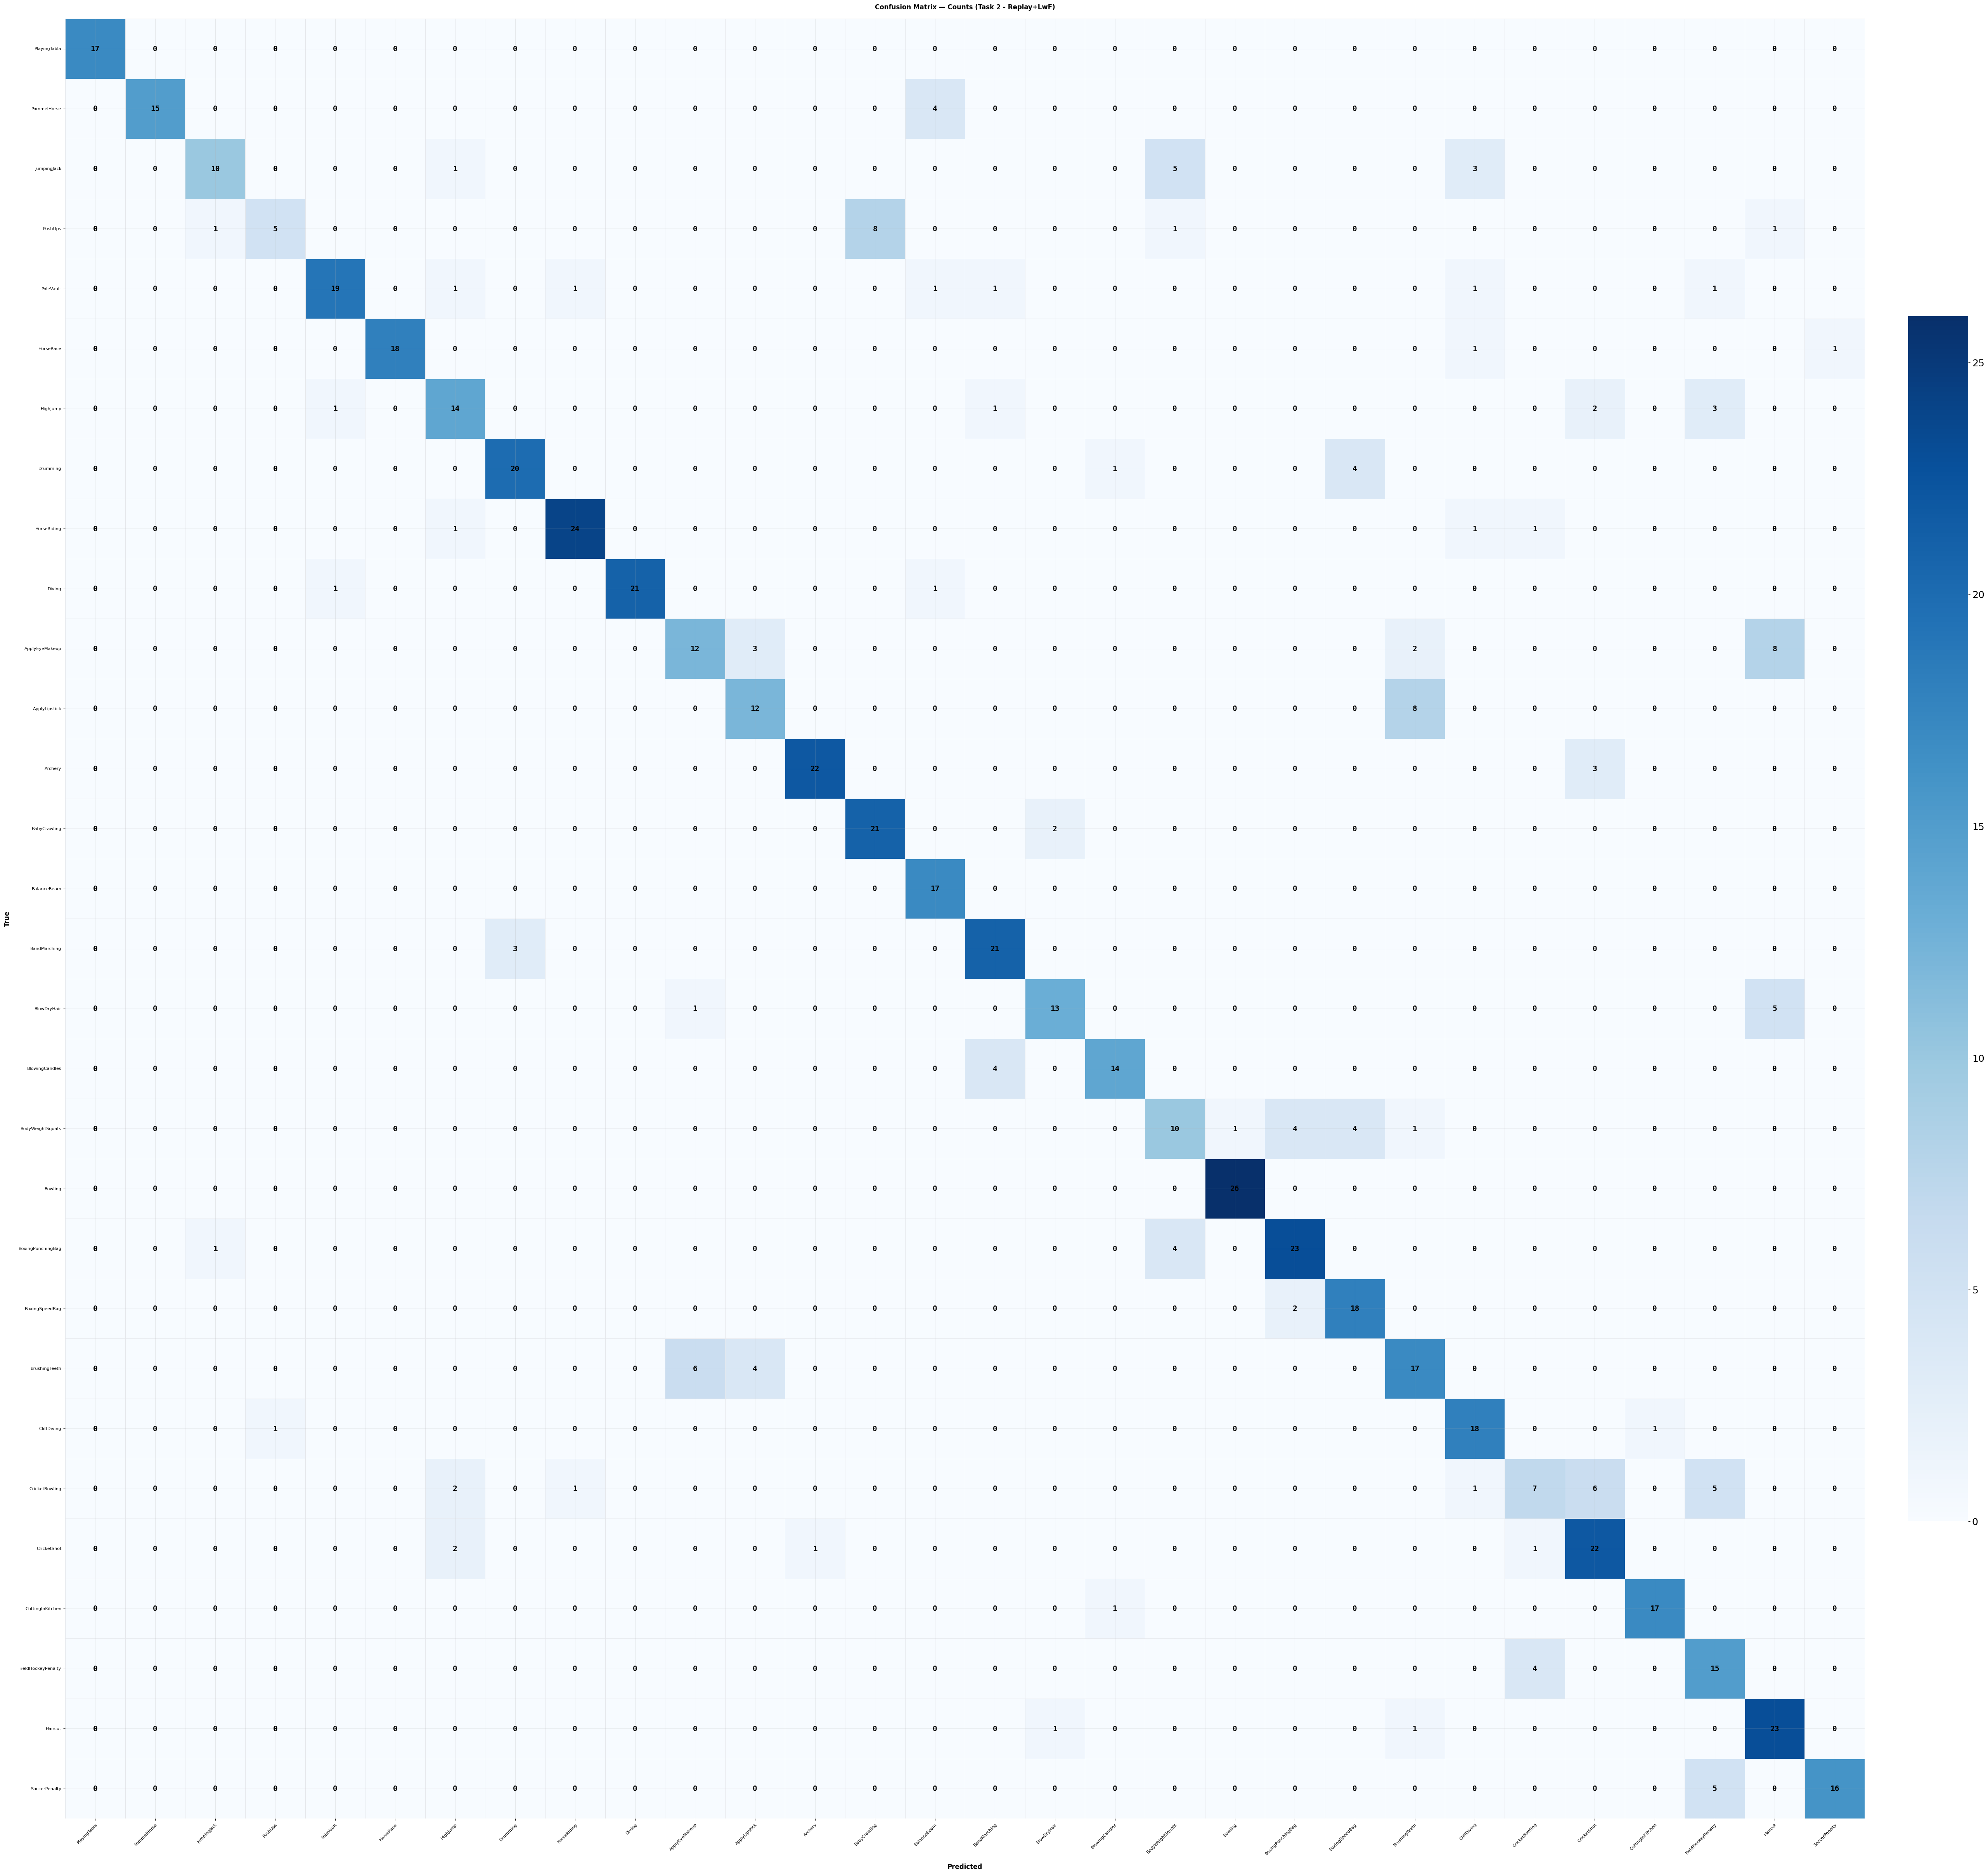

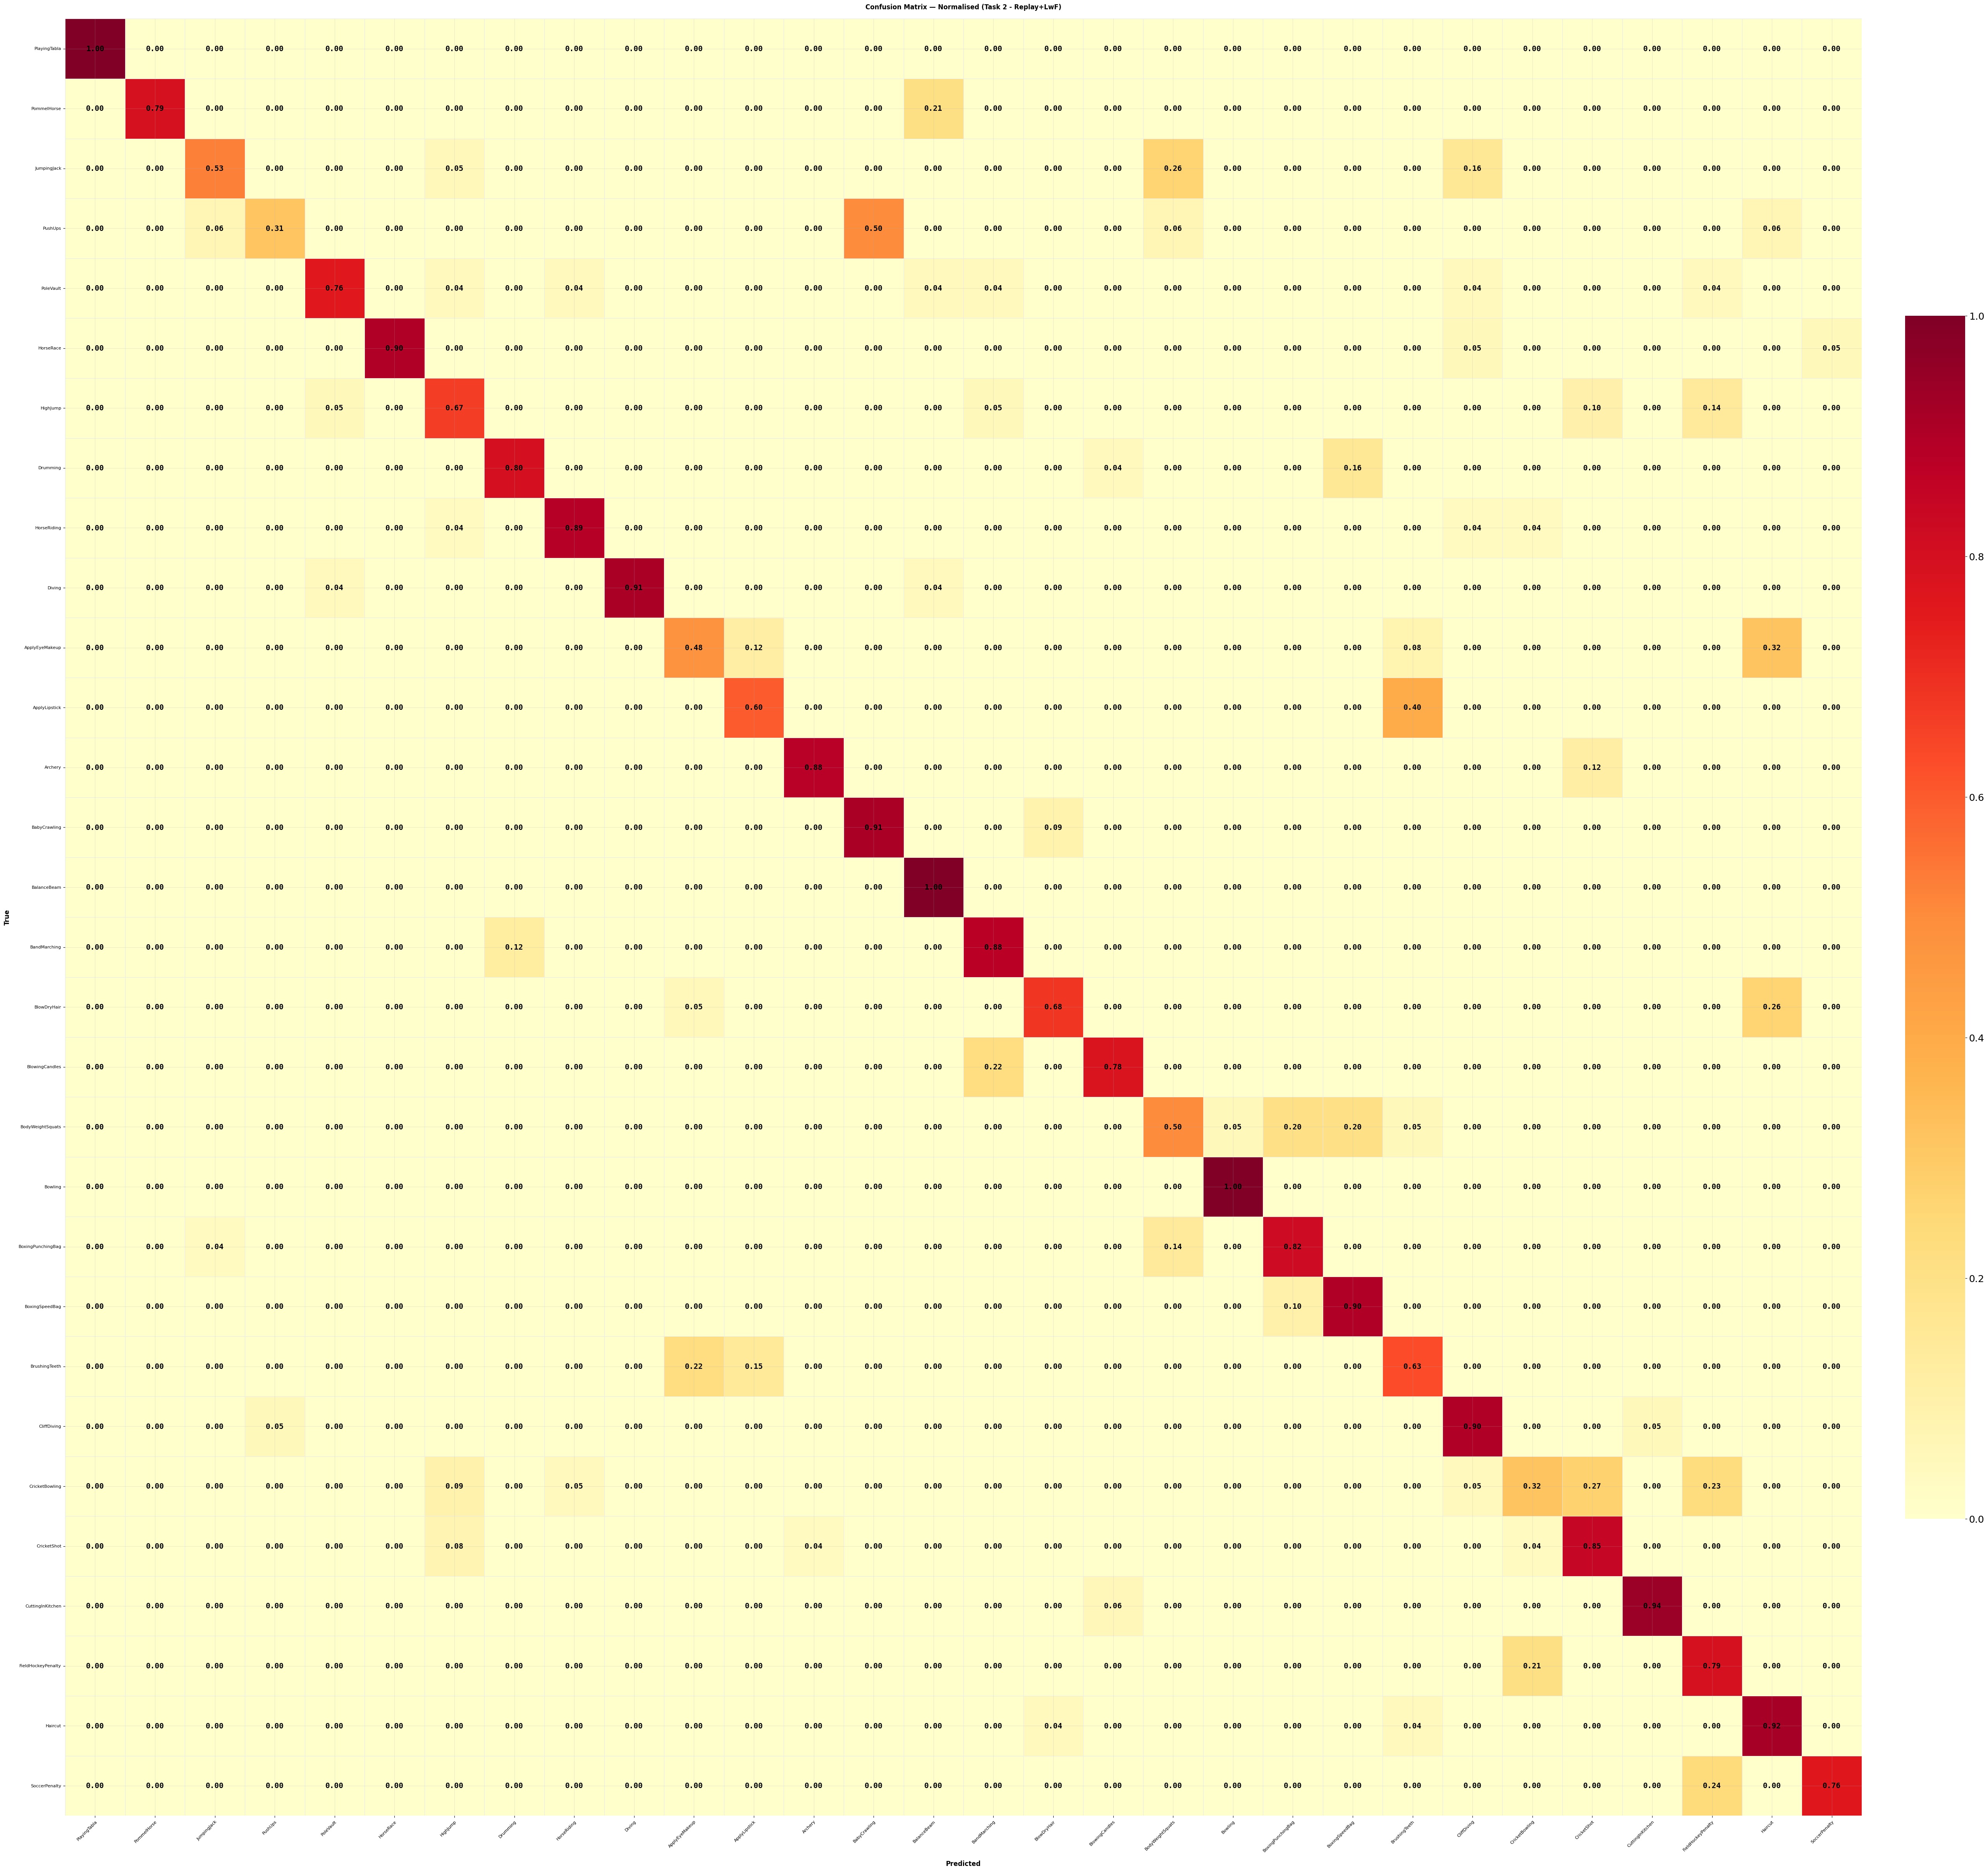

In [24]:
_, all_preds, all_labels = test_model(model_task2, combined_test_loader2, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    name         = f"Task 2 - {ARM_NAME}",
)

In [25]:
print_detailed_metrics(
    all_labels   = all_labels,
    all_preds    = all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    split_old    = (0, len(cfg.SELECTED_CLASSES)),
    split_new    = (len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)),
)


METRICS FOR 30 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.7740
  Precision : 0.7870
  Recall    : 0.7740
  F1-Score  : 0.7697

PER-CLASS REPORT 
                    precision    recall  f1-score   support

      PlayingTabla       1.00      1.00      1.00        17
       PommelHorse       1.00      0.79      0.88        19
       JumpingJack       0.83      0.53      0.65        19
           PushUps       0.83      0.31      0.45        16
         PoleVault       0.90      0.76      0.83        25
         HorseRace       1.00      0.90      0.95        20
          HighJump       0.67      0.67      0.67        21
          Drumming       0.87      0.80      0.83        25
       HorseRiding       0.92      0.89      0.91        27
            Diving       1.00      0.91      0.95        23
    ApplyEyeMakeup       0.63      0.48      0.55        25
     ApplyLipstick       0.63      0.60      0.62        20
           Archery       0.96      0.88      0.92        25
     

## **Latent Space**

In [26]:
preds_emb, labels_emb = predict_head(head_task2, CACHE, [0, 1, 2], device)

res_emb = report_accuracy(preds_emb, labels_emb, TASK_CLASSES, TASK_NAMES, class_to_idx,
                          title=f"FINAL - EMBEDDINGS ({ARM_NAME})")


  FINAL - EMBEDDINGS (Replay+LwF)
  Base         76.89%   (212 clips, 10 classes)
  Task1        77.42%   (217 clips, 10 classes)
  Task2        77.88%   (226 clips, 10 classes)
  ----------------------------------------------------------
  COMBINED     77.40%   (655 clips, all classes)
  mean/task    77.39%


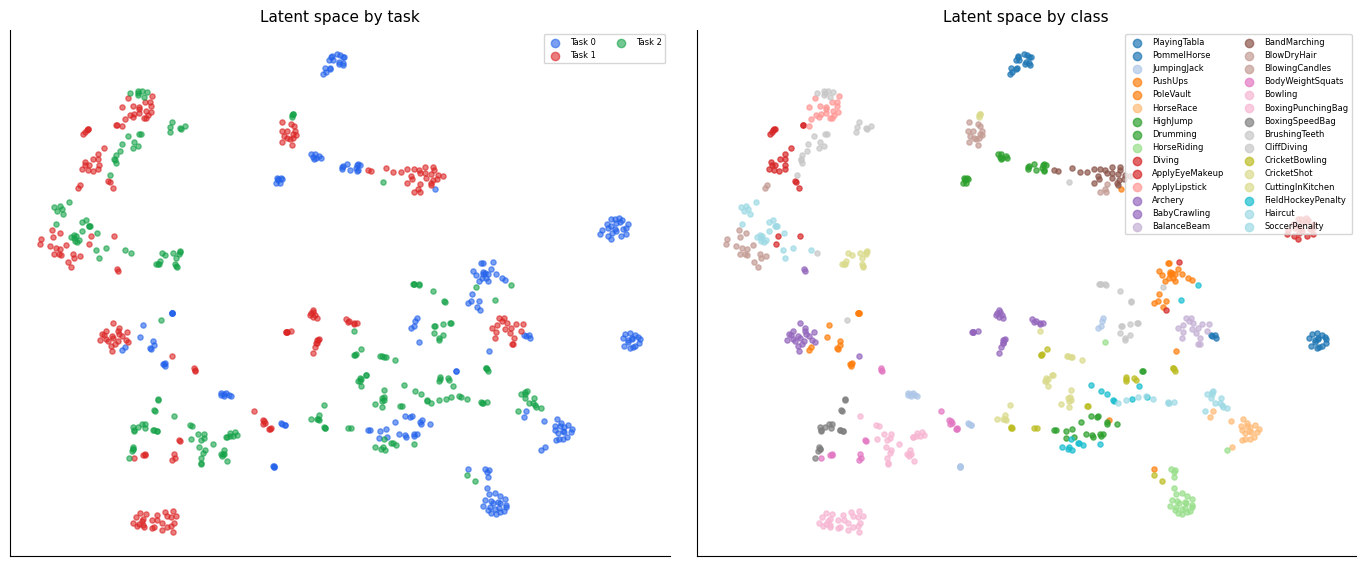

In [27]:
xy, lab = project_head_space(head_task2, CACHE, [0, 1, 2], device, seed=cfg.SEED)
task_of = {class_to_idx[c]: t for t, g in enumerate(TASK_CLASSES) for c in g}

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plot_latent_space(xy, lab, ALL_CLASSES_LIST, task_of=task_of,
                  title="Latent space by task", ax=ax[0])
plot_latent_space(xy, lab, ALL_CLASSES_LIST,
                  title="Latent space by class", ax=ax[1])
plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/latent_{ARM_KEY}.png", dpi=150, bbox_inches="tight")
plt.show()

## **Evaluation on Real Images**

In [28]:
if not clips_available(TASK_ROOTS, "test"):
    print("Raw clips not found. Re-run the Preprocess cell to evaluate on real images.")
    res_real = None
else:
    backbone = load_frozen_backbone(
        device, ResNet50LSTMTeacher, cfg.RESNET50_PATH,
        hidden_size=cfg.TEACHER_HIDDEN, num_classes=len(cfg.SELECTED_CLASSES),
        dropout_p=cfg.DROPOUT_P, remap_fn=remap_teacher_checkpoint,
    )
    full_model = FullModel(backbone, head_task2, backbone_dim=cfg.BACKBONE_DIM).to(device)

    real_loader = clip_loaders(TASK_ROOTS, TASK_CLASSES, class_to_idx, "test",
                               batch_size=cfg.BATCH_SIZE, num_workers=cfg.NUM_WORKERS)[1]
    preds_real, labels_real = predict(full_model, real_loader, device)

    res_real = report_accuracy(preds_real, labels_real, TASK_CLASSES, TASK_NAMES,
                               class_to_idx, title=f"FINAL - REAL IMAGES ({ARM_NAME})")

  Dropped 53 num_batches_tracked buffer(s).

  FINAL - REAL IMAGES (Replay+LwF)
  Base         96.49%   (171 clips, 10 classes)
  Task1        75.74%   (169 clips, 10 classes)
  Task2        76.84%   (177 clips, 10 classes)
  ----------------------------------------------------------
  COMBINED     82.98%   (517 clips, all classes)
  mean/task    83.02%


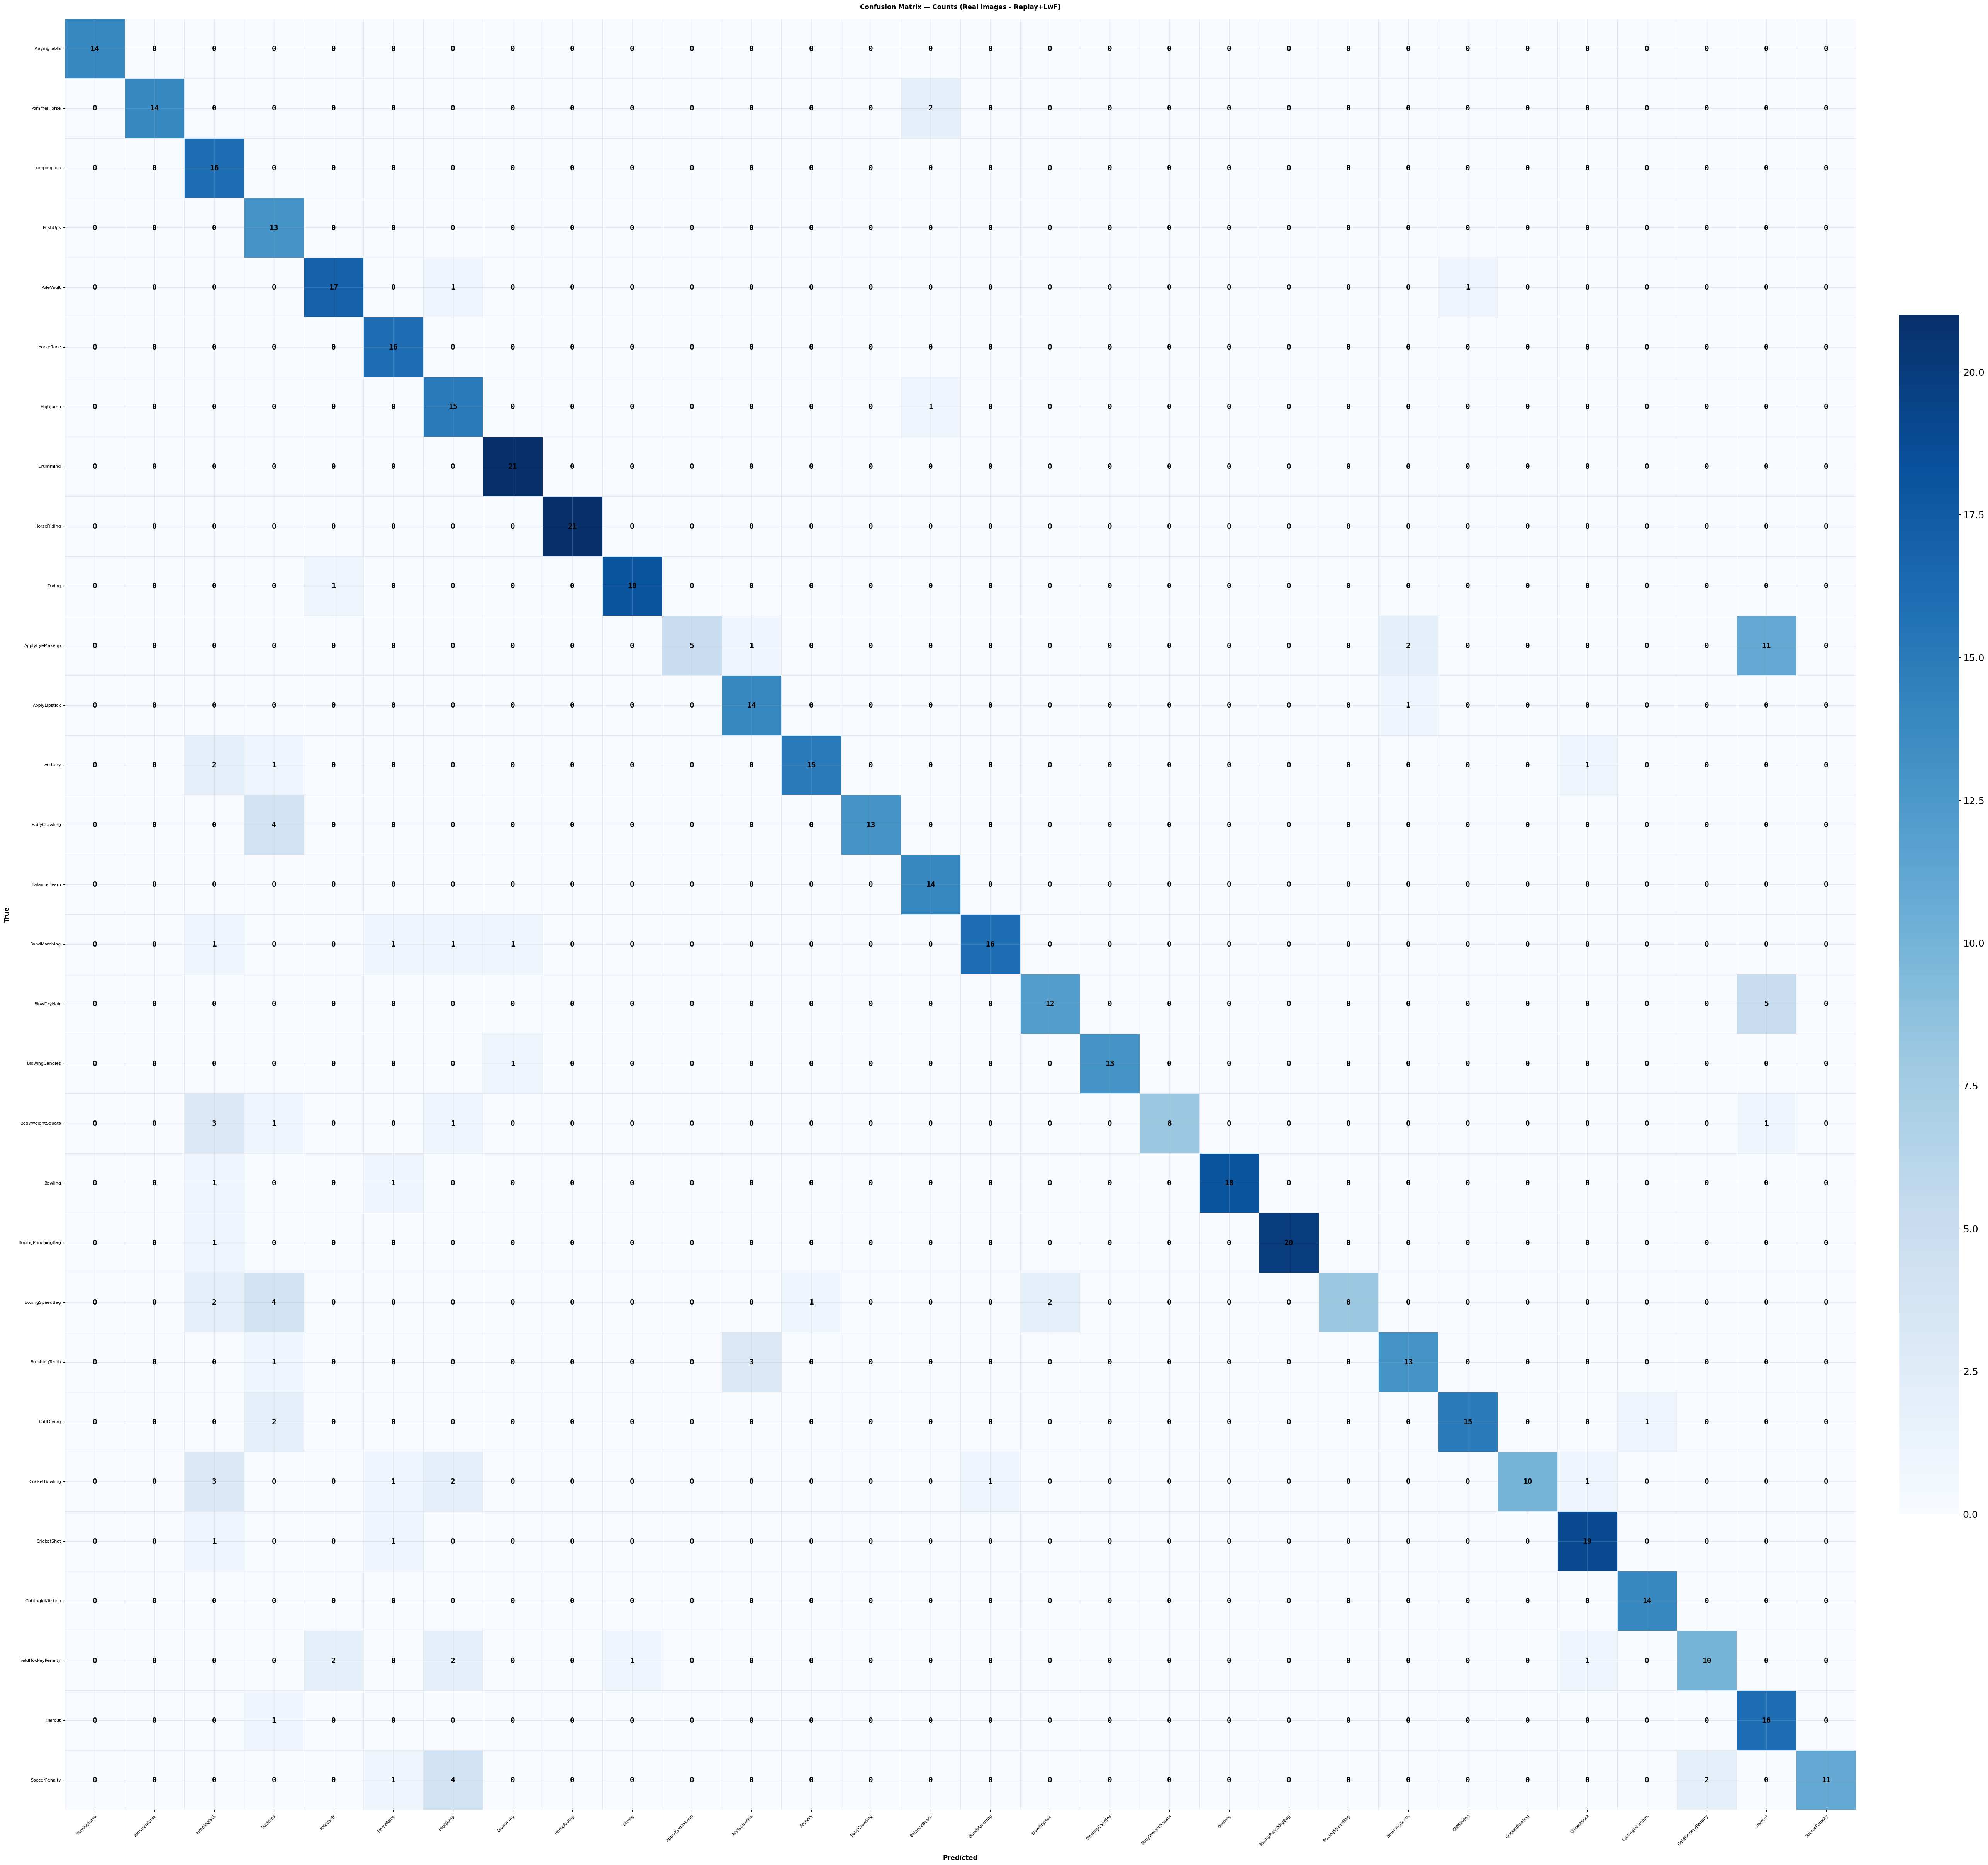

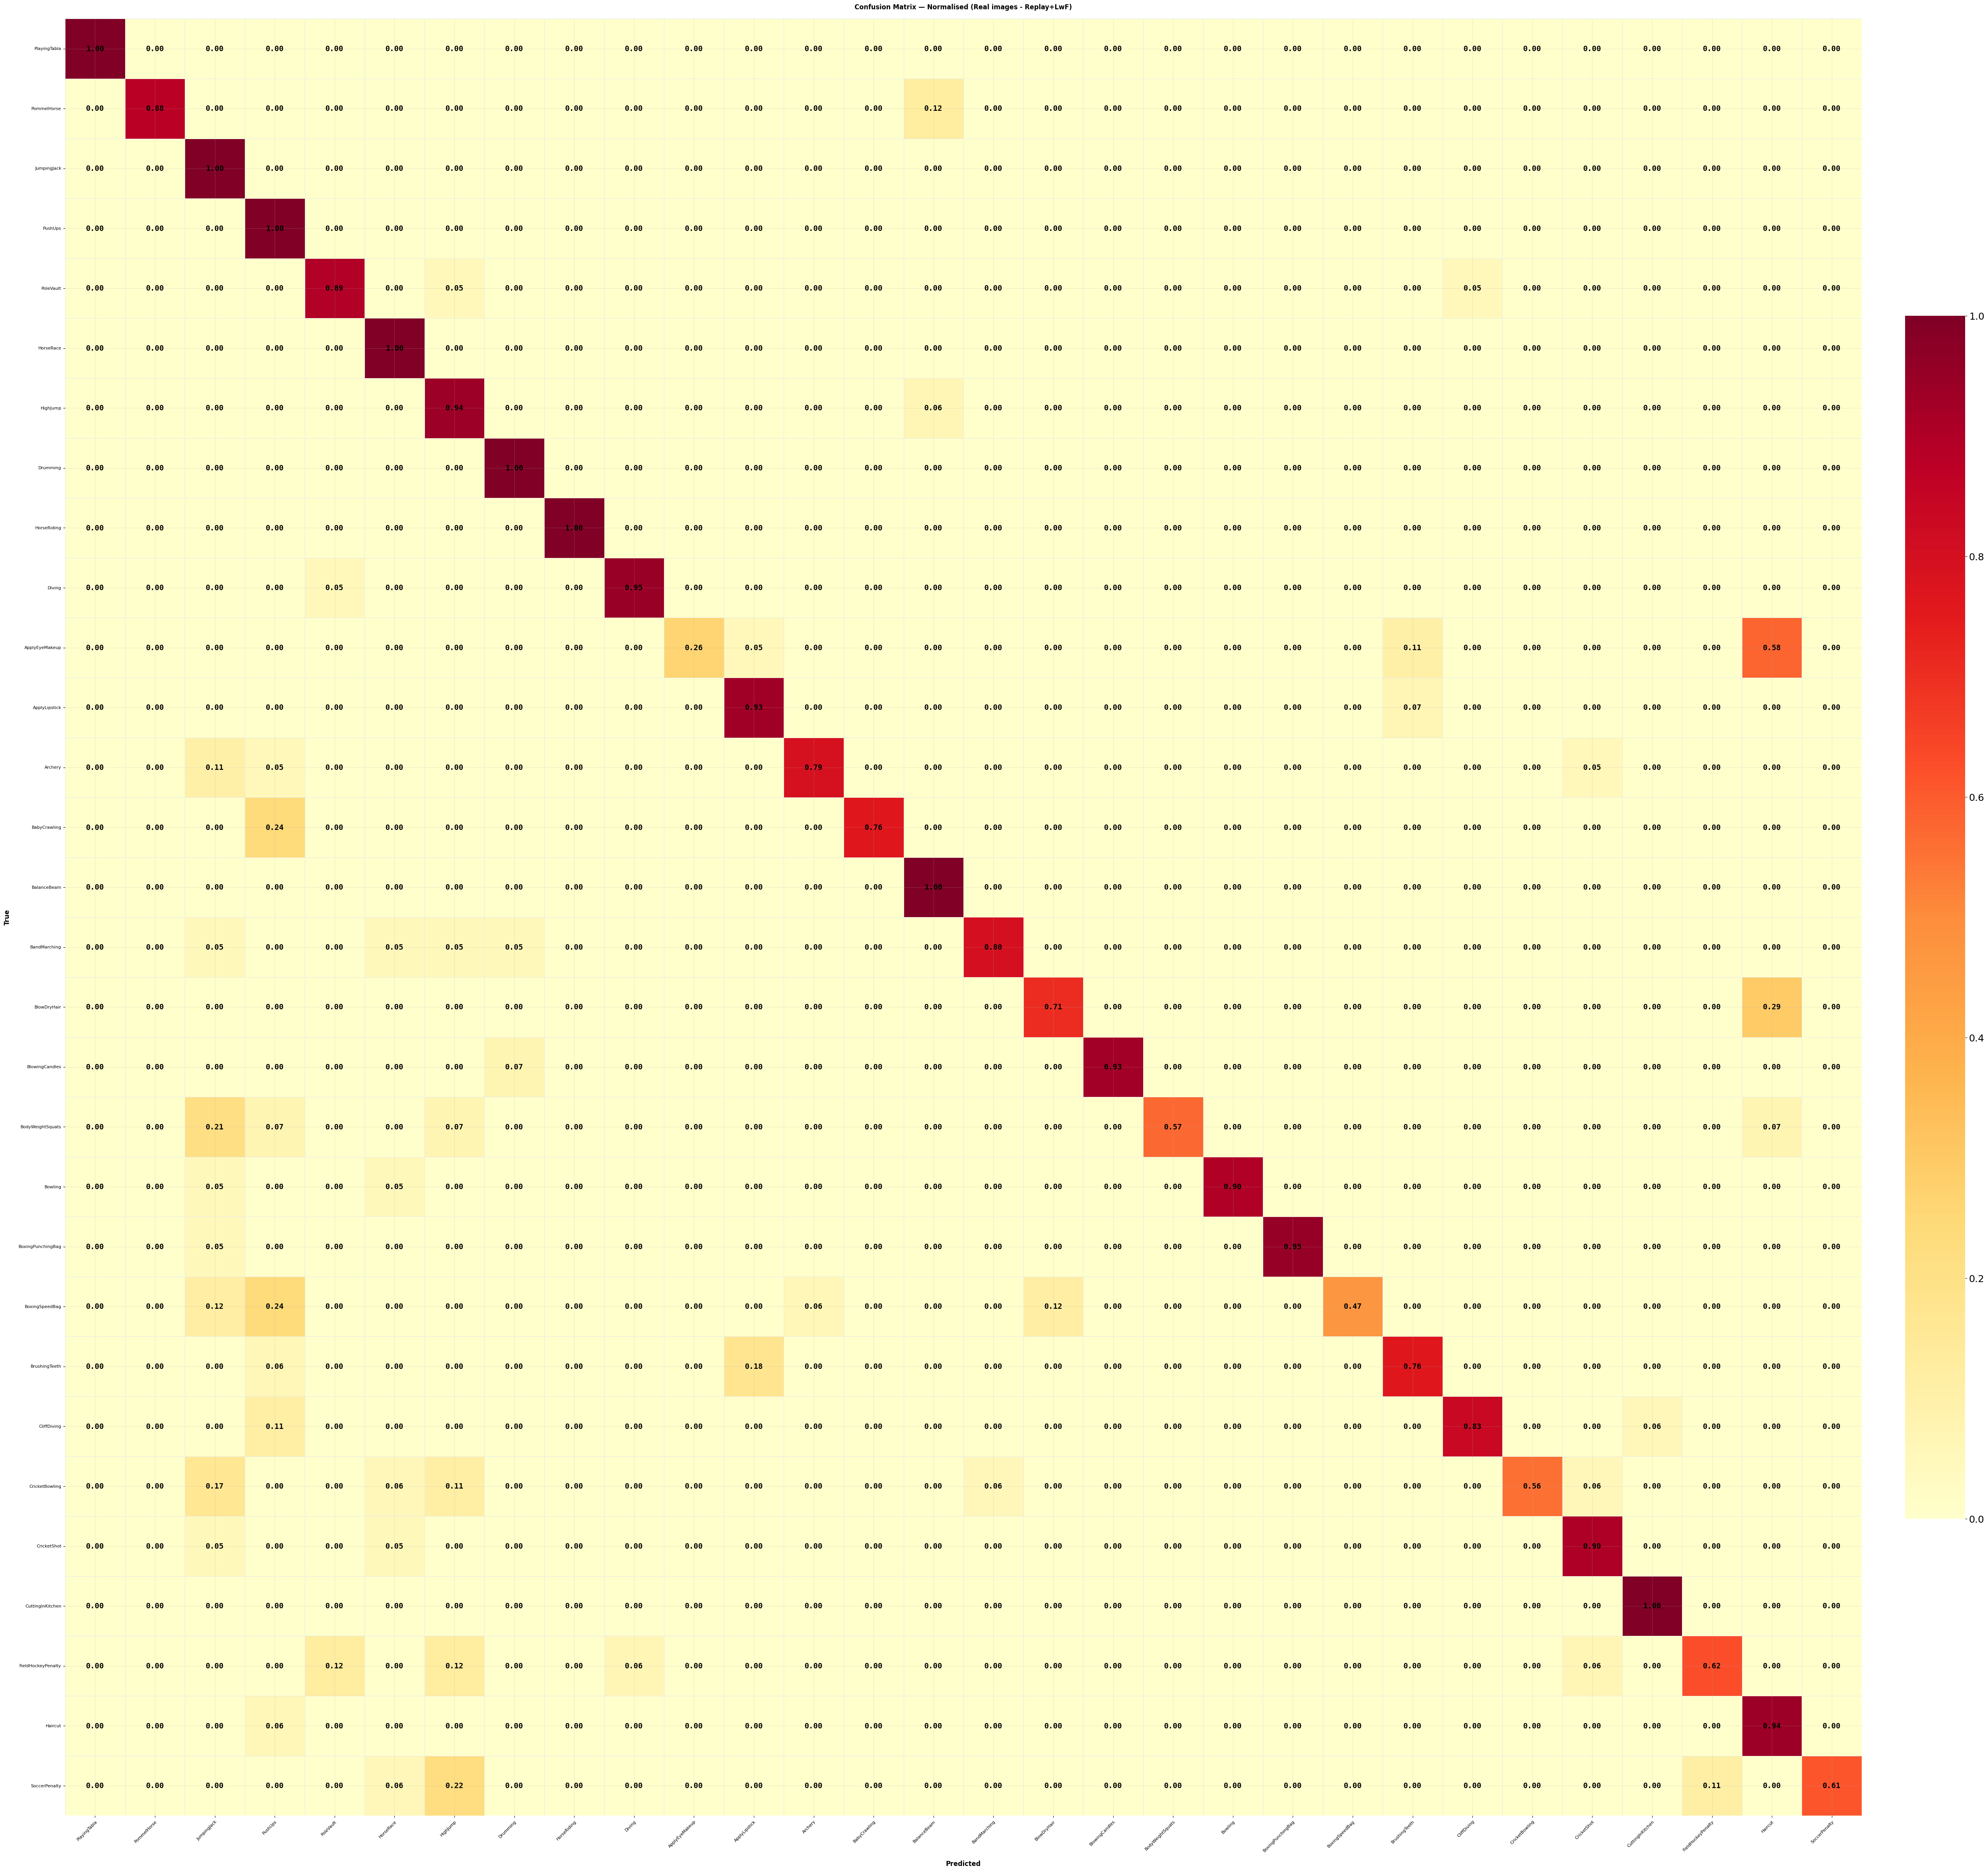


  EMBEDDINGS vs REAL IMAGES
  Split          embeddings   real images     diff
  ----------------------------------------------------------
  Base               76.89%        96.49%  +19.60%
  Task1              77.42%        75.74%   -1.68%
  Task2              77.88%        76.84%   -1.04%
  ----------------------------------------------------------
  COMBINED           77.40%        82.98%   +5.57%


In [29]:
if res_real is not None:
    plot_confusion_matrix(
        labels_real, preds_real,
        num_classes  = len(ALL_CLASSES_LIST),
        classes_list = ALL_CLASSES_LIST,
        name         = f"Real images - {ARM_NAME}",
    )

    compare_embeddings_vs_real(res_emb, res_real, TASK_NAMES)

## **Save**

In [30]:
# per-task rows, captured before Task 2 mutates head_task1 in place
ROWS = [
    {0: eval_head(head_base, *task_split(CACHE, 0, "test"), device)},
    {0: results_after_t1["base"]["accuracy"],
     1: results_after_t1["task1_only"]["accuracy"]},
    {0: results_after_t2["base"]["accuracy"],
     1: results_after_t2["task1_only"]["accuracy"],
     2: results_after_t2["task2_only"]["accuracy"]},
]
BYTES_PER_CLASS = buffer_bytes_per_class(buffer, 15) if "buffer" in dir() else 0

R, m = save_arm_result(f"{cfg.RESULTS_DIR}/stage1_arm_{ARM_KEY}.json",
                       ARM_NAME, ROWS, TASK_NAMES, BYTES_PER_CLASS,
                       config=ARM_CONFIG, ceiling=None)
cl_report(R, ARM_NAME, TASK_NAMES)
torch.save(head_task2.state_dict(), f"{cfg.CKPT_DIR}/head_{ARM_KEY}.pt")

with open(f"{cfg.RESULTS_DIR}/stage1_final_{ARM_KEY}.json", "w") as f:
    json.dump({"embeddings": res_emb, "real_images": res_real}, f, indent=2, default=float)


Replay+LwF: AA=77.39%  BWT=-13.08%  base=76.89%  mem=1966 KB/class
Saved -> /content/drive/MyDrive/apai/results/stage1_arm_replay_lwf.json

  CL REPORT — Replay+LwF
  After \ On  |   Base |  Task1 |  Task2
  --------------------------------------
  Task 0       | 91.98% |      — |      —
  Task 1       | 81.13% | 88.48% |      —
  Task 2       | 76.89% | 77.42% | 77.88%
  Average Accuracy (AA)  : 77.39%
  Forgetting Measure (F) : 13.08%
  Backward Transfer (BWT): -13.08%
  Forward Transfer  (FWT): +0.00%
